SCENARIO 1: K-MEANS CLUSTERING

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

# Display dataset
print(df.head())

# Select required features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Check missing values
print("\nMissing Values:\n", X.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [10]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

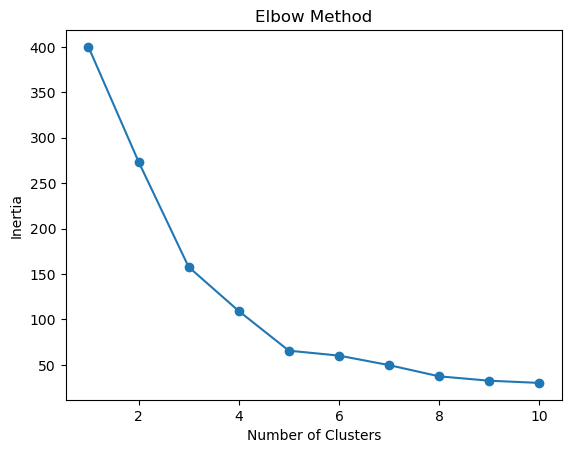

In [11]:
# Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [12]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
df['Cluster'] = clusters

# Evaluation
print("\nInertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))


Inertia: 65.56840815571682
Silhouette Score: 0.5546571631111091


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


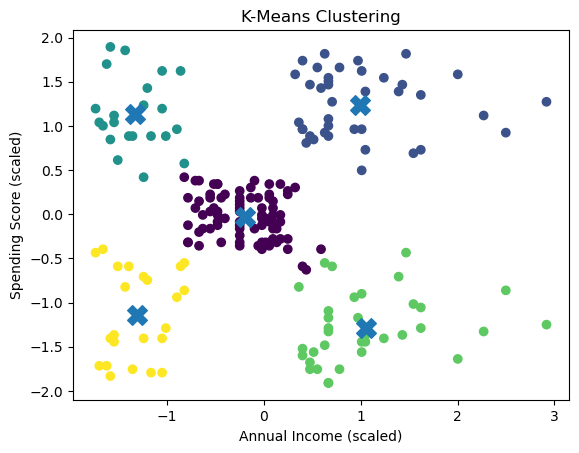

In [13]:
# Visualization
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

In [14]:
# Cluster Interpretation
print("\nCluster Means:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())


Cluster Means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


SCENARIO 2: GMM CLUSTERING

In [15]:
from sklearn.mixture import GaussianMixture

df = pd.read_csv("Mall_Customers.csv")

# Display dataset
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Check missing values
print("\nMissing Values:\n", X.isnull().sum())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [16]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose number of components (BIC)
bic_scores = []

for n in range(1, 11):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

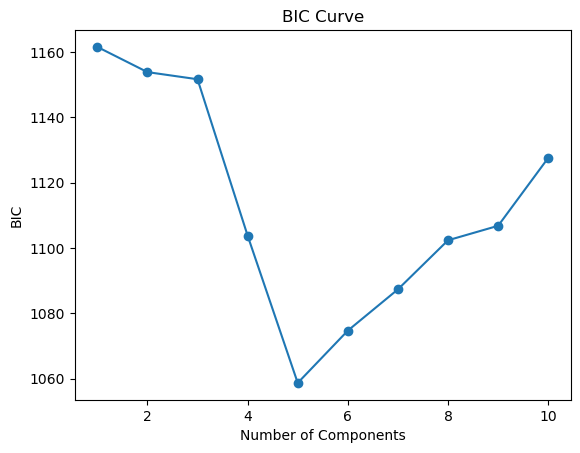

In [17]:
# Plot BIC Curve
plt.plot(range(1, 11), bic_scores, marker='o')
plt.title("BIC Curve")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.show()

In [18]:
# Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict clusters
gmm_clusters = gmm.predict(X_scaled)

# Predict probabilities
probabilities = gmm.predict_proba(X_scaled)

# Add cluster labels
df['GMM_Cluster'] = gmm_clusters

# Evaluation
print("\nLog Likelihood:", gmm.score(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, gmm_clusters))



Log Likelihood: -2.262502621973241
BIC: 1058.6522524191894
AIC: 963.0010487892964
Silhouette Score: 0.5536892843811245


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


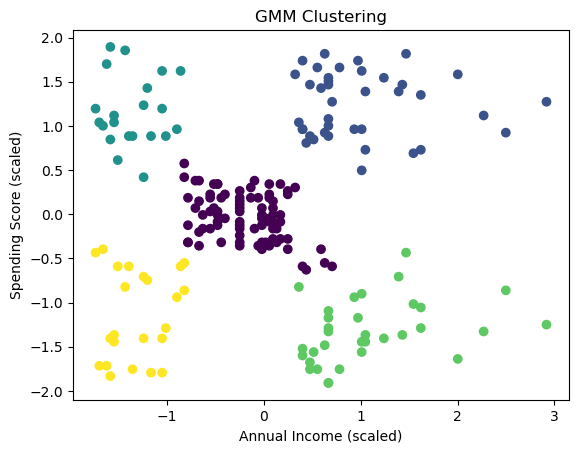

In [19]:
# Visualization 1: GMM Clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_clusters)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

In [20]:
# Visualization 2: Probability Distribution
print("\nCluster Probabilities (first 5 rows):")
print(probabilities[:5])


Cluster Probabilities (first 5 rows):
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


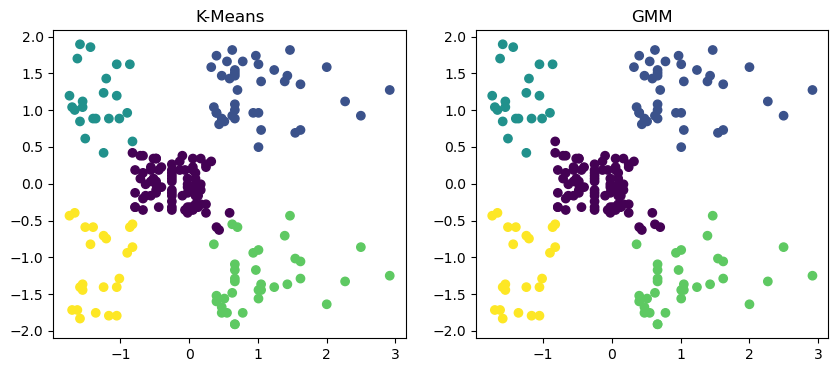

In [21]:
# Visualization 3: Comparison (K-Means vs GMM)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_clusters)
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_clusters)
plt.title("GMM")

plt.show()